In [1]:
import numpy as np
from astropy import units as u, constants as const
from matplotlib import pyplot as plt
import matplotlib as mpl
import sys, os
#sys.path.append('../simplify')
sys.path.append('../')
import importlib, lf_model, lf_optimizer, lf_plotter, utils, mass_function
importlib.reload(mass_function)
importlib.reload(utils)
importlib.reload(lf_model)
importlib.reload(lf_optimizer)
importlib.reload(lf_plotter)
from lf_model import *
from lf_plotter import LFPlotter
from lf_optimizer import run_optimize, LFOptimizer
utils.my_mpl()
from scipy.interpolate import interp1d, interp2d
import scipy.optimize

path = './lf/by_name/'

In [2]:
fuzzynames = ['CDM',  'Schive DPL', 'Schive m20', 'Marsh DPL', 'Schive B21', 'log-prior', 'Schive TPL', 'Jefferys log', 'Jefferys inv']
fuzzymodels = [FiducialCLF,  ReciprocalFuzzyCLF, ReciprocalFuzzy20CLF, MarshCLF, ReciprocalFuzzyCLF, FuzzyCLF, ShallowFuzzyCLF, FuzzyJefferysCLF, ReciprocalFuzzyJefferysCLF]
fuzzydirs = [path + mod.__name__ for mod in fuzzymodels]
fuzzydirs[4] = fuzzydirs[4] + '_21'
plotter_fuzzy = LFPlotter(fuzzydirs, names=fuzzynames, ModelClass=fuzzymodels)

/root/fdm-uvlf/utils.py:166: RuntimeWarning: divide by zero encountered in log
  logy = np.log(y)


FileNotFoundError: [Errno 2] No such file or directory: '../simplify/lf/marsh_mf/inv_log_spacing500_to_z20.npz'

In [3]:
for i, mod in enumerate(plotter_fuzzy.models): 
    print(mod.name)
    print(mod.params)
    x = plotter_fuzzy.mcmc_results(burn_in=15000, which_model=i, supress_print=True)
    if i >= 0:
        m22s = x[-1][1:][0]
        print(x)
        actual_m = [[m[-3], f'{(1/m[-2]):.2f}'] for m in m22s]
        print(actual_m)
        plotter_fuzzy.initialize_optimize(burn_in=15000, which_model=i)

CDM
[  1.69806125   1.54234242   1.12072633 -23.77842519  11.92152266]
[['$p$', [(-5, 1.581125719852, -0.114202228351), (-4, 1.589116591273, -0.10621135693), (-3, 1.614700446516, -0.080627501687), (-2, 1.640738493729, -0.054589454473), (-1, 1.667671878467, -0.027656069735), (0, 1.695327948203, 0.0), (1, 1.724326320892, 0.02899837269), (2, 1.756033383146, 0.060705434944), (3, 1.790634626484, 0.095306678281), (4, 1.825672399518, 0.130344451316), (5, 1.850902086062, 0.155574137859)]], ['$q$', [(-5, 0.992379394945, -0.577860211903), (-4, 1.040685777645, -0.529553829203), (-3, 1.166785073613, -0.403454533235), (-2, 1.289559081741, -0.280680525107), (-1, 1.422822929329, -0.147416677519), (0, 1.570239606848, 0.0), (1, 1.749012511199, 0.178772904351), (2, 1.995739155838, 0.42549954899), (3, 2.347082834225, 0.776843227377), (4, 2.493540459214, 0.923300852366), (5, 2.498684403375, 0.928444796527)]], ['$r$', [(-5, 0.524544611634, -0.597846331052), (-4, 0.643243700802, -0.479147241884), (-3, 0.776

/home/jsipple/.conda/envs/jsipple/lib/python3.7/site-packages/scipy/optimize/_minimize.py:516: RuntimeWarning: Method Nelder-Mead cannot handle constraints nor bounds.
  RuntimeWarning)


Optimization terminated successfully. 178.83058907846228 [  1.69804444   1.54239724   1.12069226 -23.77845003  11.92154174]
Schive DPL
[ 1.69804589e+00  1.54238442e+00  1.12076580e+00 -2.37785332e+01
  1.19215632e+01  5.46934484e-07]
[['$p$', [(-5, 1.577980534263, -0.113334342027), (-4, 1.587660375371, -0.103654500919), (-3, 1.610533235155, -0.080781641135), (-2, 1.636500346698, -0.054814529592), (-1, 1.66359656135, -0.027718314941), (0, 1.691314876291, 0.0), (1, 1.720492895445, 0.029178019154), (2, 1.752324802757, 0.061009926467), (3, 1.786499743725, 0.095184867434), (4, 1.820218114359, 0.128903238068), (5, 1.849794934332, 0.158480058041)]], ['$q$', [(-5, 0.994470553721, -0.578569238865), (-4, 1.046427173631, -0.526612618955), (-3, 1.169052371384, -0.403987421201), (-2, 1.293125504012, -0.279914288574), (-1, 1.42543703288, -0.147602759706), (0, 1.573039792586, 0.0), (1, 1.752372374216, 0.17933258163), (2, 1.994453888516, 0.421414095931), (3, 2.348751804625, 0.775712012039), (4, 2.4906

../simplify/lf_model.py:923: RuntimeWarning: invalid value encountered in double_scalars
  self.M0_schive = 1.6e10 * self.m_FDM22**(-4/3)


Optimization terminated successfully. 178.83059039248258 [ 1.69805952e+00  1.54226085e+00  1.12069817e+00 -2.37785008e+01
  1.19215425e+01  1.73108581e-07]
Schive m20
[ 1.69567146e+00  1.54667657e+00  1.12076706e+00 -2.37879417e+01
  1.19253655e+01  2.11942230e-04]
[['$p$', [(-5, 1.57235956473, -0.118391594145), (-4, 1.58346706135, -0.107284097525), (-3, 1.607819564978, -0.082931593898), (-2, 1.634424896837, -0.056326262038), (-1, 1.661959421312, -0.028791737563), (0, 1.690751158875, 0.0), (1, 1.721180838518, 0.030429679643), (2, 1.753988281297, 0.063237122422), (3, 1.789683302575, 0.0989321437), (4, 1.827828789121, 0.137077630246), (5, 1.838324002015, 0.14757284314)]], ['$q$', [(-5, 0.968009265341, -0.608391686436), (-4, 1.049131046614, -0.527269905163), (-3, 1.162265318663, -0.414135633114), (-2, 1.286559600244, -0.289841351534), (-1, 1.422353343799, -0.154047607979), (0, 1.576400951777, 0.0), (1, 1.764422459466, 0.188021507688), (2, 2.025226116814, 0.448825165037), (3, 2.38519518031

...

Optimization terminated successfully. 178.830589074496 [ 1.69805154e+00  1.54237780e+00  1.12067443e+00 -2.37784661e+01
  1.19215415e+01  2.81276968e-05]
Marsh DPL
[0. 0. 0. 0. 0. 0.]
[['$p$', [(-5, 1.537726820049, -0.147862497956), (-4, 1.581035558289, -0.104553759716), (-3, 1.602467233463, -0.083122084543), (-2, 1.629644482077, -0.055944835928), (-1, 1.657543657551, -0.028045660455), (0, 1.685589318006, 0.0), (1, 1.71481450394, 0.029225185934), (2, 1.746947016077, 0.061357698071), (3, 1.781882332006, 0.096293014), (4, 1.817009300388, 0.131419982383), (5, 1.836913681926, 0.15132436392)]], ['$q$', [(-5, 0.947415385347, -0.626722695792), (-4, 1.052238564329, -0.521899516811), (-3, 1.164565266504, -0.409572814635), (-2, 1.290048214667, -0.284089866472), (-1, 1.425902087254, -0.148235993885), (0, 1.574138081139, 0.0), (1, 1.754370859722, 0.180232778583), (2, 2.001771606016, 0.427633524877), (3, 2.349627758532, 0.775489677393), (4, 2.495697912728, 0.921559831589), (5, 2.499533547375, 0.925

../simplify/utils.py:41: RuntimeWarning: divide by zero encountered in log
  return np.log(np.maximum(x, lower_bound)) / np.log(base)


Optimization terminated successfully. 178.91722078510253 [ 1.69163750e+00  1.56515241e+00  1.13568371e+00 -2.38368973e+01
  1.19408632e+01 -4.78557645e-08]
Schive B21
[0. 0. 0. 0. 0. 0.]
[['$p$', [(-5, 1.420687202386, -0.382238903579), (-4, 1.465540344775, -0.33738576119), (-3, 1.549370988213, -0.253555117753), (-2, 1.638736727576, -0.16418937839), (-1, 1.721179977337, -0.081746128628), (0, 1.802926105966, 0.0), (1, 1.894196961913, 0.091270855948), (2, 2.000150069881, 0.197223963915), (3, 2.123597739049, 0.320671633083), (4, 2.266089338009, 0.463163232044), (5, 2.295476889001, 0.492550783036)]], ['$q$', [(-5, 0.905545155139, -0.427504862986), (-4, 0.919059847457, -0.413990170667), (-3, 1.023733331461, -0.309316686664), (-2, 1.123986423712, -0.209063594412), (-1, 1.223136710472, -0.109913307652), (0, 1.333050018125, 0.0), (1, 1.461787491893, 0.128737473768), (2, 1.629420969922, 0.296370951798), (3, 1.869462929871, 0.536412911746), (4, 2.342077585732, 1.009027567607), (5, 2.420273734192,

../simplify/lf_model.py:978: RuntimeWarning: invalid value encountered in double_scalars
  self.M0_schive = 1.6e10 * self.m_FDM22**(-4/3)


Optimization terminated successfully. 178.83059667837463 [ 1.69800649e+00  1.54269791e+00  1.12076394e+00 -2.37786010e+01
  1.19216199e+01  2.81192998e-07]


$p$ [(-3, 1.610533235155, -0.080781641135), (-2, 1.636500346698, -0.054814529592), (-1, 1.66359656135, -0.027718314941), (0, 1.691314876291, 0.0), (1, 1.720492895445, 0.029178019154), (2, 1.752324802757, 0.061009926467), (3, 1.786499743725, 0.095184867434)]
$q$ [(-3, 1.169052371384, -0.403987421201), (-2, 1.293125504012, -0.279914288574), (-1, 1.42543703288, -0.147602759706), (0, 1.573039792586, 0.0), (1, 1.752372374216, 0.17933258163), (2, 1.994453888516, 0.421414095931), (3, 2.348751804625, 0.775712012039)]
$r$ [(-3, 0.771806154133, -0.348087921069), (-2, 0.896170325499, -0.223723749703), (-1, 1.011326107102, -0.108567968099), (0, 1.119894075201, 0.0), (1, 1.226810944526, 0.106916869324), (2, 1.334733696964, 0.214839621763), (3, 1.442156389559, 0.322262314358)]
$M_{\rm UV,0}$ [(-3, -24.309907228029, -0.52007056804), (-2, -24.1390240068, -0.349187346811), (-1, -23.965326966369, -0.17549030638), (0, -23.789836659989, 0.0), (1, -23.604641752156, 0.185194907833), (2, -23.400606006095, 0.

[['$p$',
  [(-3, 1.610533235155, -0.080781641135),
   (-2, 1.636500346698, -0.054814529592),
   (-1, 1.66359656135, -0.027718314941),
   (0, 1.691314876291, 0.0),
   (1, 1.720492895445, 0.029178019154),
   (2, 1.752324802757, 0.061009926467),
   (3, 1.786499743725, 0.095184867434)]],
 ['$q$',
  [(-3, 1.169052371384, -0.403987421201),
   (-2, 1.293125504012, -0.279914288574),
   (-1, 1.42543703288, -0.147602759706),
   (0, 1.573039792586, 0.0),
   (1, 1.752372374216, 0.17933258163),
   (2, 1.994453888516, 0.421414095931),
   (3, 2.348751804625, 0.775712012039)]],
 ['$r$',
  [(-3, 0.771806154133, -0.348087921069),
   (-2, 0.896170325499, -0.223723749703),
   (-1, 1.011326107102, -0.108567968099),
   (0, 1.119894075201, 0.0),
   (1, 1.226810944526, 0.106916869324),
   (2, 1.334733696964, 0.214839621763),
   (3, 1.442156389559, 0.322262314358)]],
 ['$M_{\\rm UV,0}$',
  [(-3, -24.309907228029, -0.52007056804),
   (-2, -24.1390240068, -0.349187346811),
   (-1, -23.965326966369, -0.1754903063

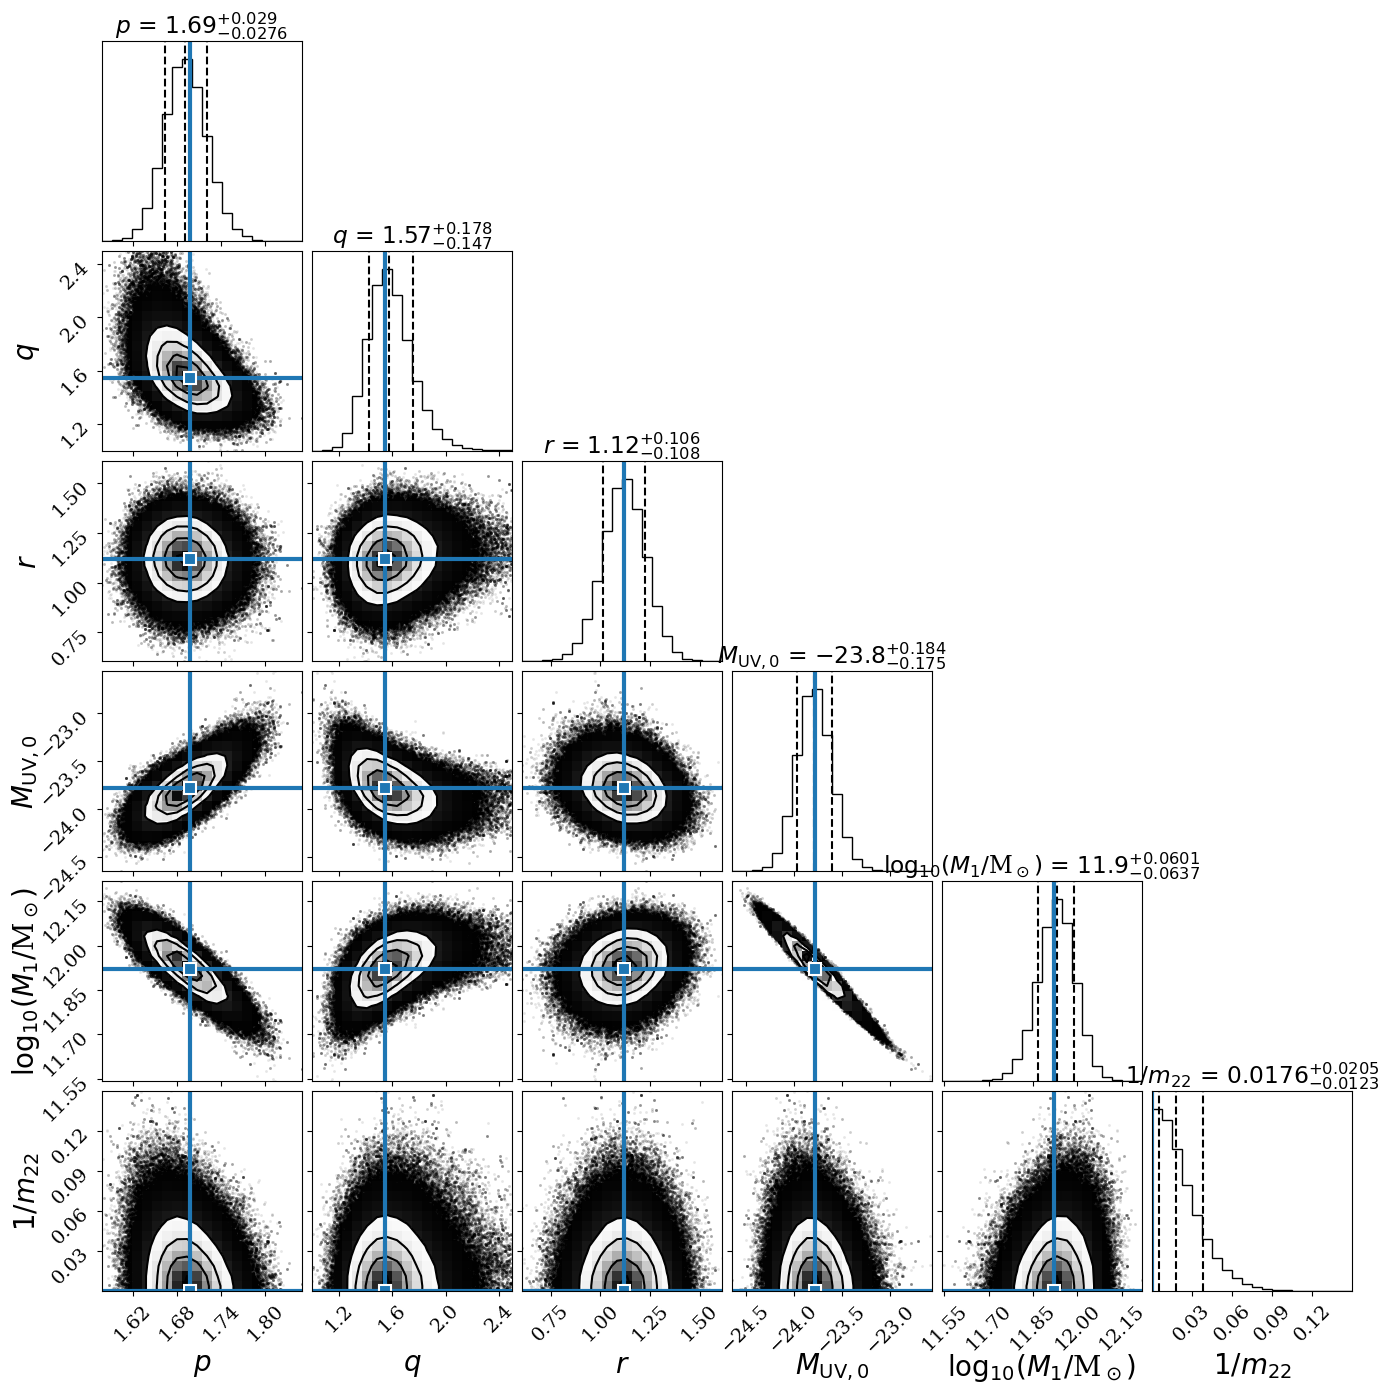

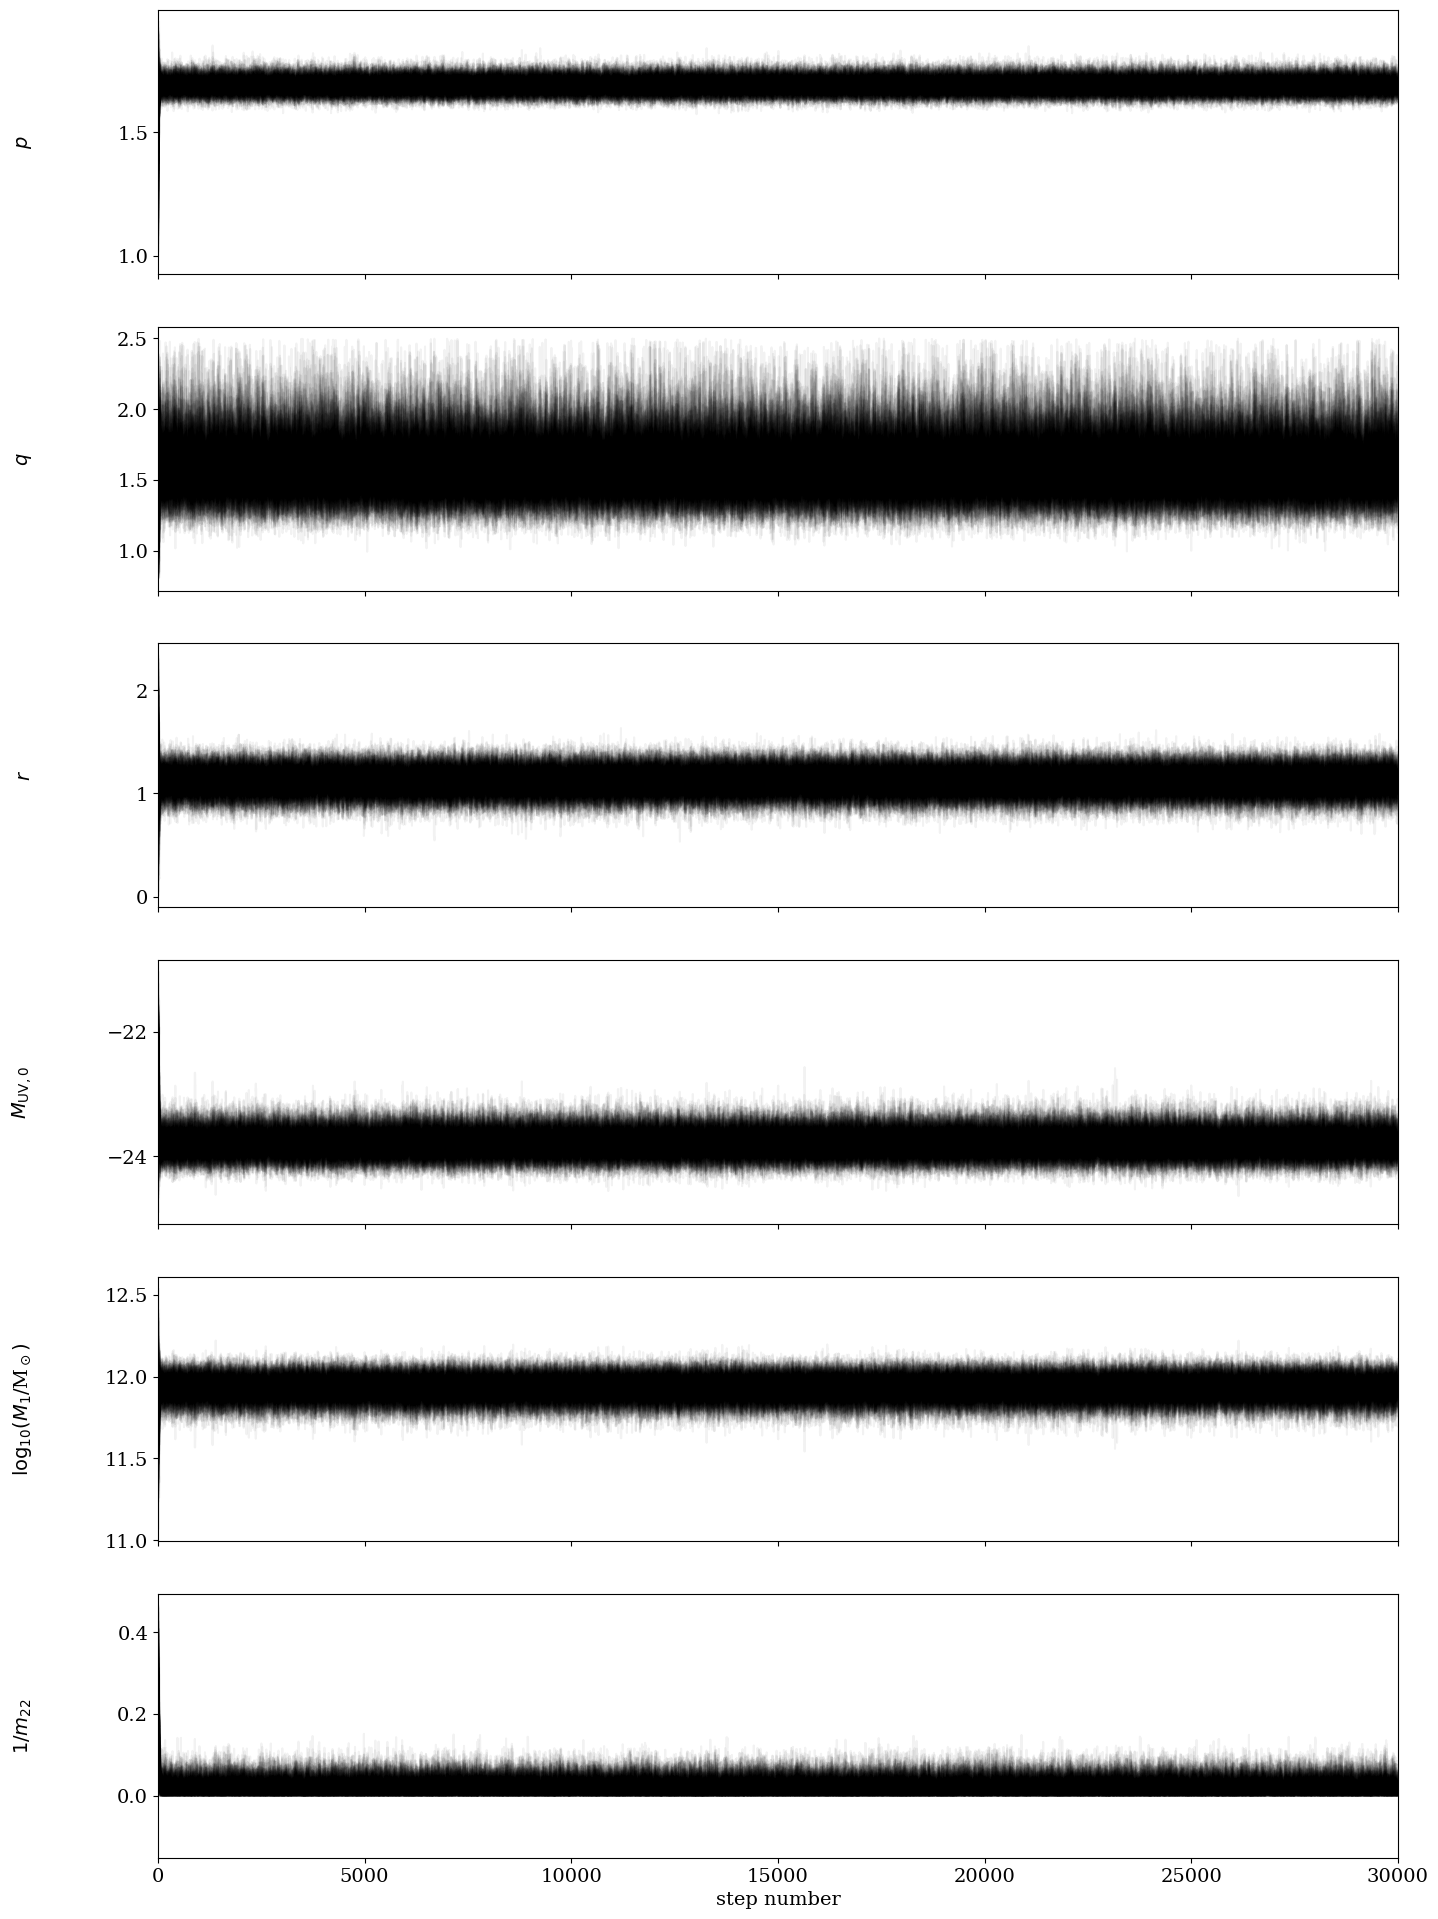

In [85]:
plotter_fuzzy.plot_corner(burn_in=15000, which_model=1, show_best=True, walkers=False, sigmas=[-3,-2,-1,0,1,2,3], levels2D=None, title_fmt='.3g')

$p$ [(-3, 1.610533235155, -0.080781641135), (-2, 1.636500346698, -0.054814529592), (-1, 1.66359656135, -0.027718314941), (0, 1.691314876291, 0.0), (1, 1.720492895445, 0.029178019154), (2, 1.752324802757, 0.061009926467), (3, 1.786499743725, 0.095184867434)]
$q$ [(-3, 1.169052371384, -0.403987421201), (-2, 1.293125504012, -0.279914288574), (-1, 1.42543703288, -0.147602759706), (0, 1.573039792586, 0.0), (1, 1.752372374216, 0.17933258163), (2, 1.994453888516, 0.421414095931), (3, 2.348751804625, 0.775712012039)]
$r$ [(-3, 0.771806154133, -0.348087921069), (-2, 0.896170325499, -0.223723749703), (-1, 1.011326107102, -0.108567968099), (0, 1.119894075201, 0.0), (1, 1.226810944526, 0.106916869324), (2, 1.334733696964, 0.214839621763), (3, 1.442156389559, 0.322262314358)]
$M_{\rm UV,0}$ [(-3, -24.309907228029, -0.52007056804), (-2, -24.1390240068, -0.349187346811), (-1, -23.965326966369, -0.17549030638), (0, -23.789836659989, 0.0), (1, -23.604641752156, 0.185194907833), (2, -23.400606006095, 0.

[['$p$',
  [(-3, 1.610533235155, -0.080781641135),
   (-2, 1.636500346698, -0.054814529592),
   (-1, 1.66359656135, -0.027718314941),
   (0, 1.691314876291, 0.0),
   (1, 1.720492895445, 0.029178019154),
   (2, 1.752324802757, 0.061009926467),
   (3, 1.786499743725, 0.095184867434)]],
 ['$q$',
  [(-3, 1.169052371384, -0.403987421201),
   (-2, 1.293125504012, -0.279914288574),
   (-1, 1.42543703288, -0.147602759706),
   (0, 1.573039792586, 0.0),
   (1, 1.752372374216, 0.17933258163),
   (2, 1.994453888516, 0.421414095931),
   (3, 2.348751804625, 0.775712012039)]],
 ['$r$',
  [(-3, 0.771806154133, -0.348087921069),
   (-2, 0.896170325499, -0.223723749703),
   (-1, 1.011326107102, -0.108567968099),
   (0, 1.119894075201, 0.0),
   (1, 1.226810944526, 0.106916869324),
   (2, 1.334733696964, 0.214839621763),
   (3, 1.442156389559, 0.322262314358)]],
 ['$M_{\\rm UV,0}$',
  [(-3, -24.309907228029, -0.52007056804),
   (-2, -24.1390240068, -0.349187346811),
   (-1, -23.965326966369, -0.1754903063

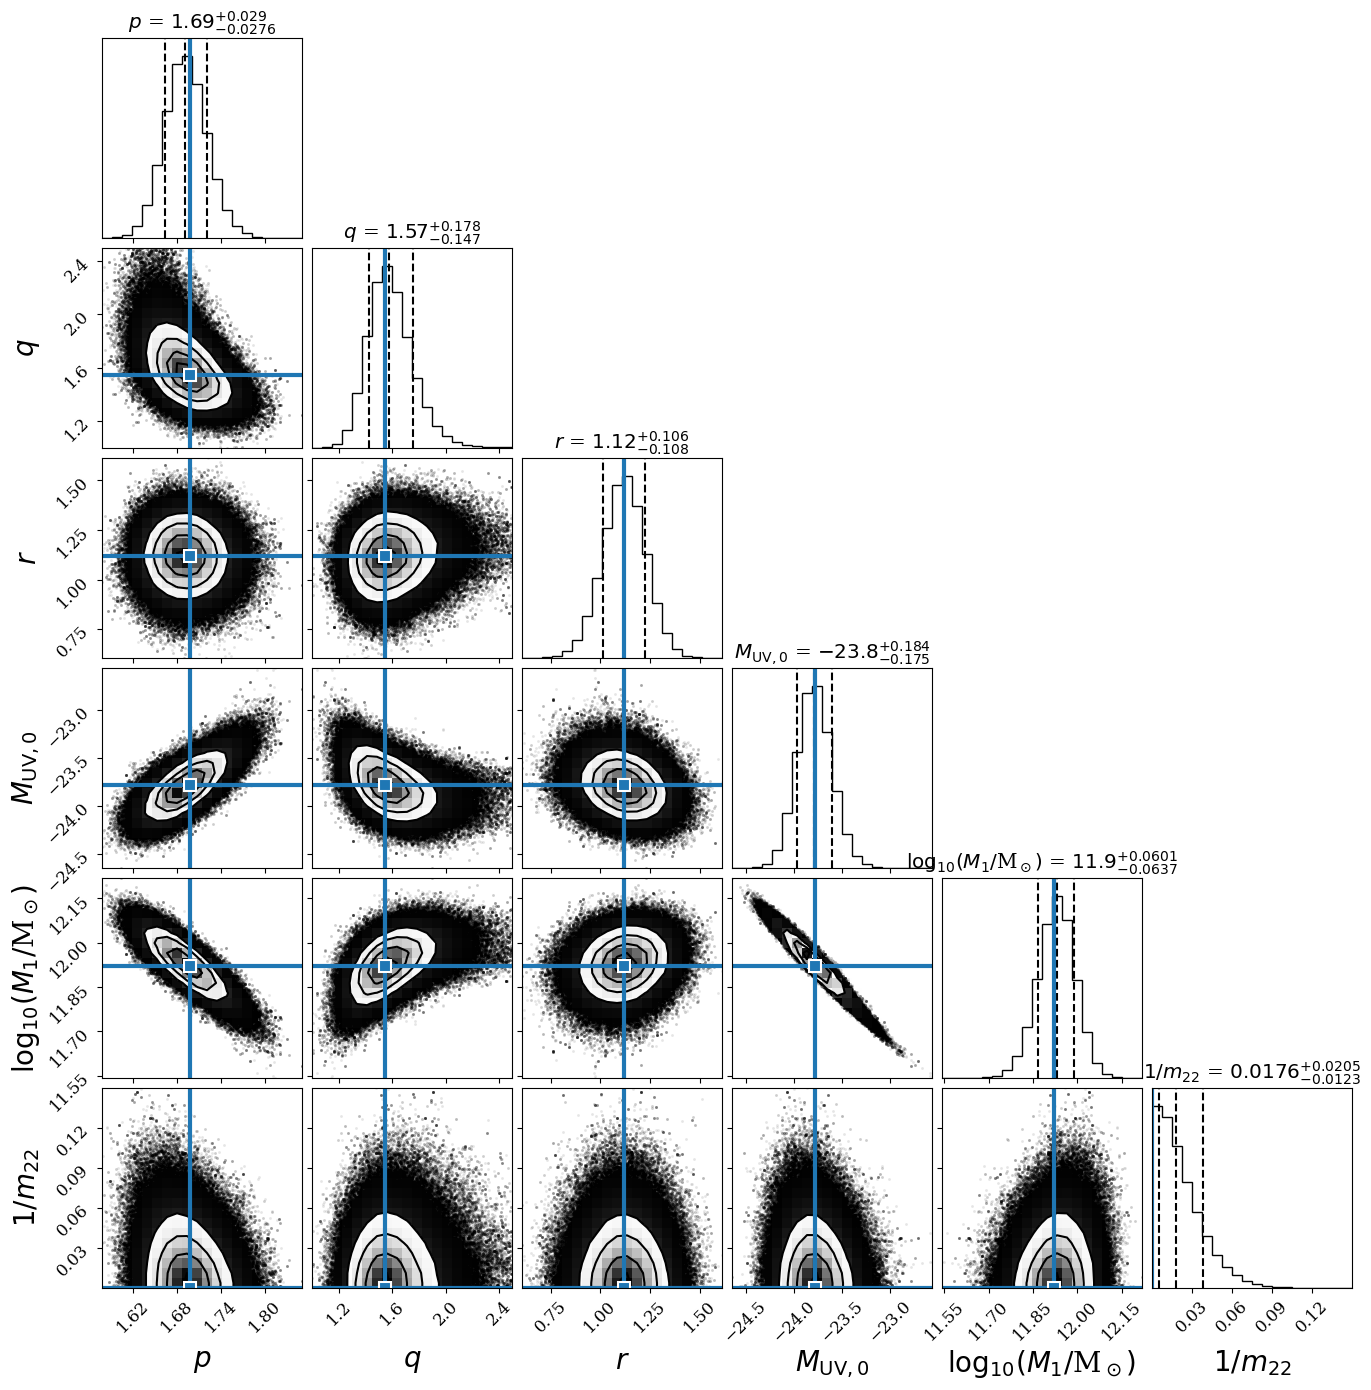

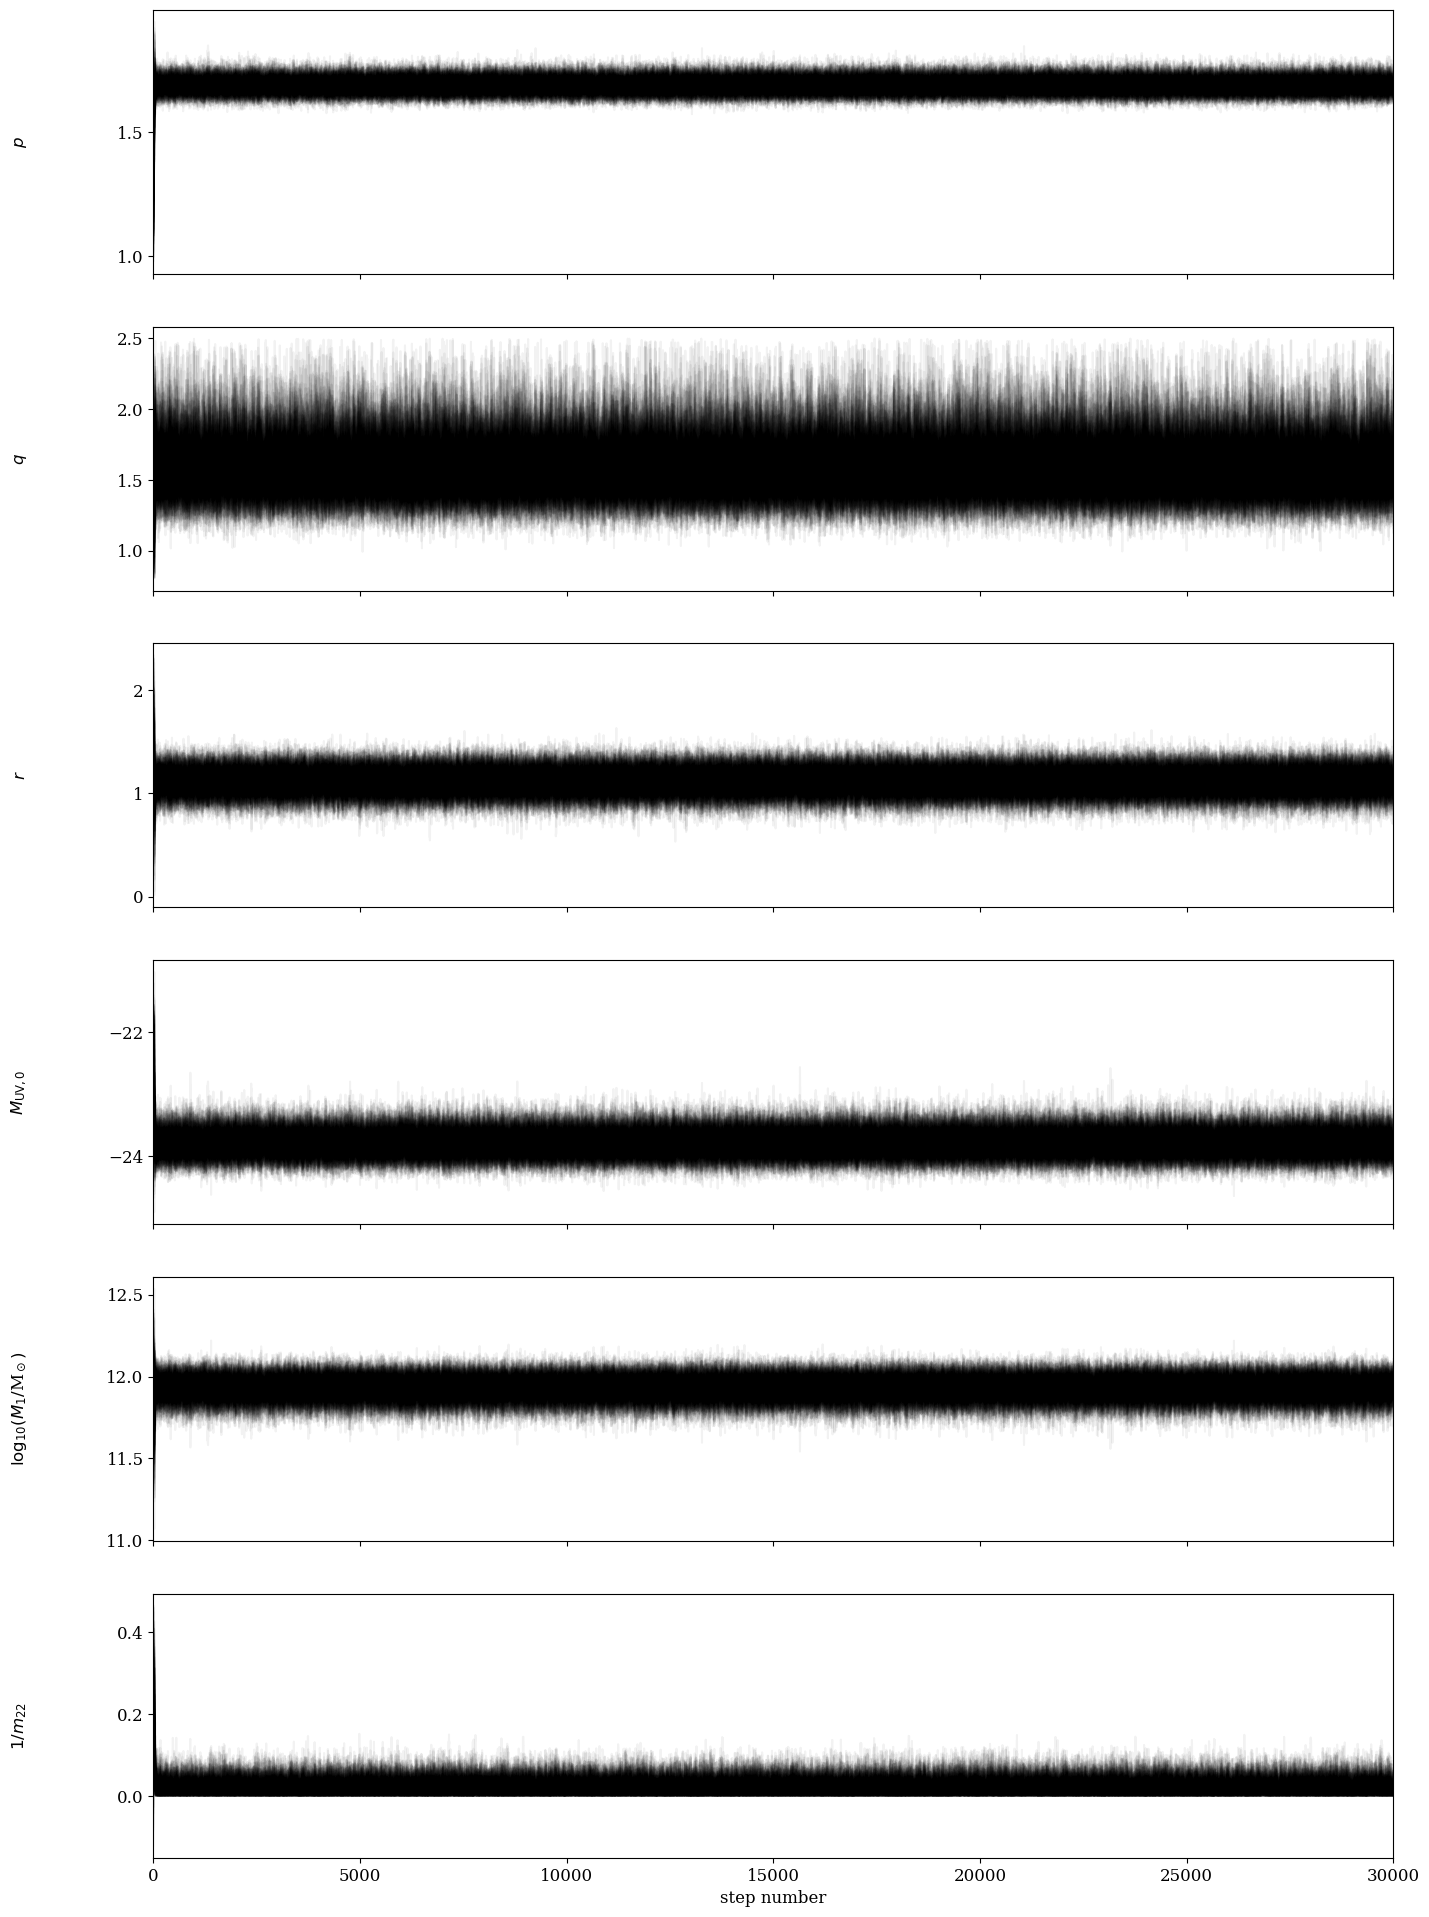

In [81]:
plotter_fuzzy.plot_corner(burn_in=15000, which_model=1, show_best=True, walkers=True, sigmas=[-3,-2,-1,0,1,2,3], levels2D=None, title_fmt='.3g')

/home/jsipple/.conda/envs/jsipple/lib/python3.7/site-packages/ipykernel_launcher.py:40: RuntimeWarning: divide by zero encountered in true_divide
/home/jsipple/.conda/envs/jsipple/lib/python3.7/site-packages/ipykernel_launcher.py:40: RuntimeWarning: divide by zero encountered in true_divide


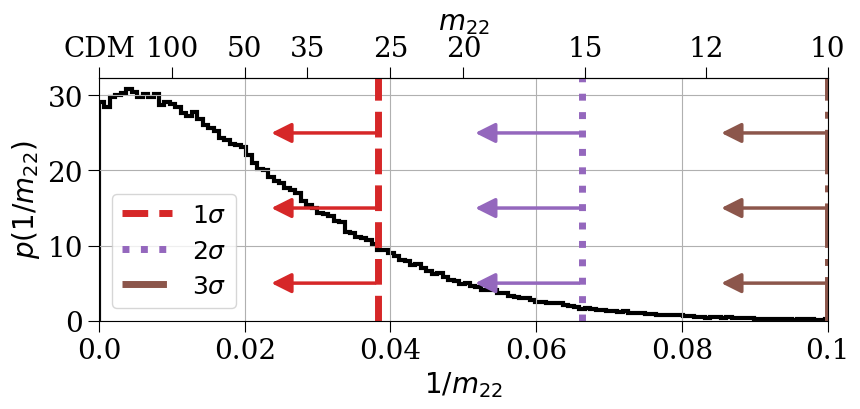

In [92]:
from scipy.stats import norm
plt.figure(figsize=(9,4.5))
self = plotter_fuzzy
sigmas = [1,2,3]
which_models = [1]
colors = ['k', 'red', 'blue', 'green', 'purple', 'orange', 'brown']
labs = ['Schive', 'Marsh', 'Jefferys Prior', 'B21', 'Log Prior', 'Log Jefferys', 'Triple Power Law']
labs = ['Schive', 'Marsh', None, 'B21', None, None, 'Triple Power Law']
for i, which_model in enumerate(which_models):
    which_param = -1
    burn_in = 15000
    reader = self.mcmc_readers[which_model]
    model = self.models[which_model]
    samples = reader.get_chain(discard=burn_in, flat=True)
    vals = samples[:, which_param]
    if labs[i] is not None and 'Log' in labs[i]:
        vals = 1/(10**vals)
    percentiles =  [100*norm.cdf(sigma) for sigma in sigmas]
    limits = np.percentile(vals, percentiles)
    alpha=1
    if i == 2 or i==4 or i==5:
        alpha=0
    plt.hist(vals, 200, color=colors[i], histtype='step', lw=3, density=True, label=None, alpha=alpha)
    #test = mpl.patches.ArrowStyle('-|>', head_length=0.4, head_width=0.2)
    for k, elem in enumerate(limits):
        c = f'C{i*3 + k + 3}' 
        plt.axvline(x=elem, ls=utils.LINESTYLE_ARR[k+1], color=c, label=rf'${k+1}\sigma$', lw=5)
        length = 0.015
        plt.annotate('', xy=(elem-length, 5), xytext=(elem, 5), arrowprops=dict(arrowstyle='-|>', color=c,zorder=99, mutation_scale=30, lw=2.5))
        plt.annotate('', xy=(elem-length, 15), xytext=(elem, 15), arrowprops=dict(arrowstyle='-|>', color=c,zorder=99, mutation_scale=30, lw=2.5))
        plt.annotate('', xy=(elem-length, 25), xytext=(elem, 25), arrowprops=dict(arrowstyle='-|>', color=c,zorder=99, mutation_scale=30, lw=2.5))

label = model.param_names[which_param]
plt.xlim(1e-5, 0.1)
#plt.ylim(None, 50)
ax1 = plt.gca()
locs, labels = plt.xticks()
plt.xticks(np.clip(locs,1e-5,np.inf), np.round(locs, 2))
def forward(x):
    return 1/x
ax2 = plt.gca().secondary_xaxis('top', functions=(forward, forward))
ax2.set_xticks([9, 10, 12, 15, 20, 25, 35, 50, 100, 100000])
ax2.set_xticklabels([9, 10, 12, 15, 20, 25, 35, 50, 100, r'CDM'])
ax2.set_xlabel(r'$m_{22}$')

plt.xlabel(r'$1/m_{22}$')
plt.ylabel(r"$p\left(1/m_{22}\right)$")
plt.legend(loc='lower left', fontsize=18)
plt.tight_layout()
plt.savefig('../simplify/lf/figs/fdm/posterior.pdf')

In [9]:
1/0.049079969288

20.37491087518873

In [39]:
plotter_fuzzy.mcmc_results(burn_in=15000, which_model=1, sigmas=[0,1,np.sqrt(2),2,3,4,5], supress_print=False, for_latex=False, decimals=12)

$p$ [(0, 1.691314876291, 0.0), (1, 1.720492895445, 0.029178019154), (1.4142135623730951, 1.733237537233, 0.041922660942), (2, 1.752324802757, 0.061009926467), (3, 1.786499743725, 0.095184867434), (4, 1.820218114359, 0.128903238068), (5, 1.849794934332, 0.158480058041)]
$q$ [(0, 1.573039792586, 0.0), (1, 1.752372374216, 0.17933258163), (1.4142135623730951, 1.842000148221, 0.268960355635), (2, 1.994453888516, 0.421414095931), (3, 2.348751804625, 0.775712012039), (4, 2.490678870036, 0.917639077451), (5, 2.49981811452, 0.926778321934)]
$r$ [(0, 1.119894075201, 0.0), (1, 1.226810944526, 0.106916869324), (1.4142135623730951, 1.271117632318, 0.151223557117), (2, 1.334733696964, 0.214839621763), (3, 1.442156389559, 0.322262314358), (4, 1.547754434184, 0.427860358983), (5, 1.603788892094, 0.483894816893)]
$M_{\rm UV,0}$ [(0, -23.789836659989, 0.0), (1, -23.604641752156, 0.185194907833), (1.4142135623730951, -23.522573321472, 0.267263338517), (2, -23.400606006095, 0.389230653894), (3, -23.156732

[['$p$',
  [(0, 1.691314876291, 0.0),
   (1, 1.720492895445, 0.029178019154),
   (1.4142135623730951, 1.733237537233, 0.041922660942),
   (2, 1.752324802757, 0.061009926467),
   (3, 1.786499743725, 0.095184867434),
   (4, 1.820218114359, 0.128903238068),
   (5, 1.849794934332, 0.158480058041)]],
 ['$q$',
  [(0, 1.573039792586, 0.0),
   (1, 1.752372374216, 0.17933258163),
   (1.4142135623730951, 1.842000148221, 0.268960355635),
   (2, 1.994453888516, 0.421414095931),
   (3, 2.348751804625, 0.775712012039),
   (4, 2.490678870036, 0.917639077451),
   (5, 2.49981811452, 0.926778321934)]],
 ['$r$',
  [(0, 1.119894075201, 0.0),
   (1, 1.226810944526, 0.106916869324),
   (1.4142135623730951, 1.271117632318, 0.151223557117),
   (2, 1.334733696964, 0.214839621763),
   (3, 1.442156389559, 0.322262314358),
   (4, 1.547754434184, 0.427860358983),
   (5, 1.603788892094, 0.483894816893)]],
 ['$M_{\\rm UV,0}$',
  [(0, -23.789836659989, 0.0),
   (1, -23.604641752156, 0.185194907833),
   (1.41421356237

In [37]:
x = 1.6*10**10 * (25)**(-4/3)
print('{:.2e}'.format(x))

2.19e+08


In [34]:
(1 + ((8e8)/(2.3e8))**-1.1)**-2.2

0.6079856869093638

In [26]:
(1 + ((1.5e9)/(4.3e8))**-1.1)**-2.2

0.6088497522030877

In [6]:
3**(4/3)

4.3267487109222245

In [4]:
print('{:.2e}'.format(plotter_fuzzy.models[0].M_from_m(m=-13, z=8)))

1.96e+09


In [3]:
print('{:.2e}'.format(plotter_fuzzy.models[0].M_from_m(m=-11, z=8)))

6.64e+08


In [3]:
cdm_params = plotter_fuzzy.models[0].params
# meas_zipped = plotter_fuzzy.models[0].meas.zipped
# for z, mag, phi, minus, plus, source in meas_zipped:
#     if True:#mag == -16.25:
#         print(z, mag, phi, minus, plus)
cdm_phi = plotter_fuzzy.models[0].phi_m
def phi_ratio(z, mag, m22, mf='s'):
    if mf is 's':
        ModClass = ReciprocalFuzzyCLF
    if mf is 'm':
        ModClass = MarshCLF
    #mp = [[cdm_params], [*cdm_params, 1/m22]]
    mp = [cdm_params] + [[*cdm_params, 1/x] for x in [m22]]
    plotter = LFPlotter([path+'FiducialCLF', path+'FiducialCLF'], ModelClass=[FiducialCLF, ModClass], manual_params=mp)
    fdm_phi = plotter.models[1].phi_m
    return fdm_phi(z=z, m=mag) / cdm_phi(z=z, m=mag)

../simplify/utils.py:119: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return np.array(extend*list(iter(x)))
../simplify/utils.py:165: RuntimeWarning: divide by zero encountered in log
  logy = np.log(y)
../simplify/utils.py:119: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return np.array(extend*list(iter(x)))
../simplify/utils.py:165: RuntimeWarning: divide by zero encountered in log
  logy = np.log(y)
../simplify/utils.py:119: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-o

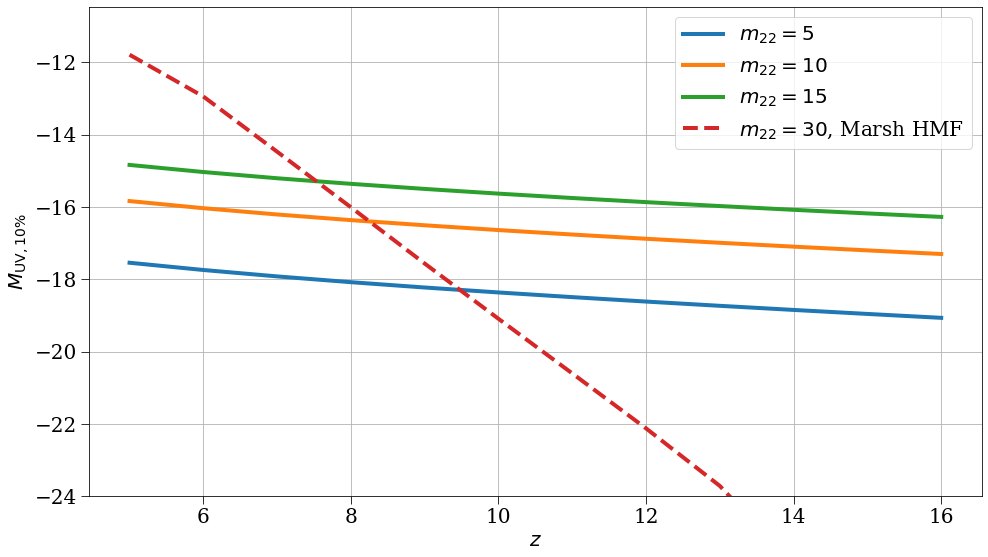

In [17]:
zvals = np.arange(5,17)

mf = 's'
m22s = [5,10,15]
for m22 in m22s:
    phi90s = []
    for z in zvals:
        def phi90_finder(mag, m22=m22, mf=mf):
            return phi_ratio(z, mag, m22, mf=mf) - 0.9
        phi90s.append(scipy.optimize.fsolve(phi90_finder, x0=-15)[0])
    plt.plot(zvals, phi90s, label=rf'$m_{{22}}={m22}$')

m22=30
phi90s = []
for z in zvals:
    def phi90_finder(mag, m22=m22, mf='m'):
        return phi_ratio(z, mag, m22, mf=mf) - 0.9
    phi90s.append(scipy.optimize.fsolve(phi90_finder, x0=-15)[0])
plt.plot(zvals, phi90s, label=rf'$m_{{22}}={m22}$, Marsh HMF', ls='--')

plt.xlabel(r'$z$')
plt.ylabel(r'$M_{\rm UV,10\%}$')
plt.ylim(-24, None)
plt.legend()

../simplify/utils.py:119: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return np.array(extend*list(iter(x)))
../simplify/utils.py:165: RuntimeWarning: divide by zero encountered in log
  logy = np.log(y)


../simplify/utils.py:119: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return np.array(extend*list(iter(x)))
../simplify/utils.py:165: RuntimeWarning: divide by zero encountered in log
  logy = np.log(y)
../simplify/utils.py:119: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return np.array(extend*list(iter(x)))
../simplify/utils.py:165: RuntimeWarning: divide by zero encountered in log
  logy = np.log(y)
../simplify/utils.py:119: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-o

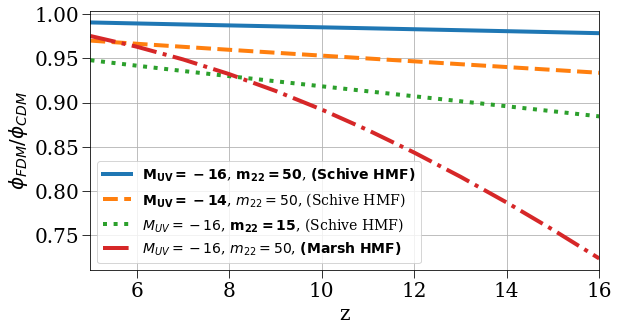

In [18]:
zvals = np.arange(5,17)
m22s = [50,15]
mags = [-16,-14]
plt.figure(figsize=[9,5])

# locs = np.zeros_like(zvals, dtype=float)
# locs2 = np.zeros_like(zvals, dtype=float)
# for z, mag, phi, minus, plus, source in meas_zipped:
#     if mag == mags[0]:
#         cdm_prediction = cdm_phi(z=z, m=mag)
#         chi_sq_cdm = utils.chi_squared(measured=phi, theory=cdm_prediction, sigma_plus=plus, sigma_minus=minus)
#         def delta_chi_minus_one(theory):
#             chi_sq =  utils.chi_squared(measured=phi, theory=theory, sigma_plus=plus, sigma_minus=minus)
#             return chi_sq - chi_sq_cdm - 1/4
#         x = scipy.optimize.fsolve(delta_chi_minus_one, x0=0)
#         loc = x/cdm_phi(z=z,m=mag)
#         locs[int(z-5)] = loc
#         print(z-5, loc, locs[int(z-5)])
#     if mag == mags[1]:
#         cdm_prediction = cdm_phi(z=z, m=mag)
#         chi_sq_cdm = utils.chi_squared(measured=phi, theory=cdm_prediction, sigma_plus=plus, sigma_minus=minus)
#         def delta_chi_minus_one(theory):
#             chi_sq =  utils.chi_squared(measured=phi, theory=theory, sigma_plus=plus, sigma_minus=minus)
#             return chi_sq - chi_sq_cdm - 1/4
#         x = scipy.optimize.fsolve(delta_chi_minus_one, x0=0)
#         loc = x/cdm_phi(z=z,m=mag)
#         if loc < 1:
#             locs2[int(z-5)] = loc
#         print(z-5, loc, locs2[int(z-5)])

# print(zvals, locs)
# plt.fill_between(zvals, locs, facecolor='gray', alpha=0.3,)
# plt.fill_between(zvals, locs2, facecolor='pink', alpha=0.5,)

kwargs = {'mag':mags[0], 'm22':m22s[0], 'mf':'s'}
plt.plot(zvals, [phi_ratio(z=z, **kwargs) for z in zvals], label=fr'$\bf{{M_{{UV}}={kwargs["mag"]}}}$, $\bf{{m_{{22}}={kwargs["m22"]}}}$, $\bf{{(Schive}}$ $\bf{{HMF)}}$', ls='-')
kwargs = {'mag':mags[1], 'm22':m22s[0], 'mf':'s'}
plt.plot(zvals, [phi_ratio(z=z, **kwargs) for z in zvals], label=fr'$\bf{{M_{{UV}}={kwargs["mag"]}}}$, $m_{{22}}={kwargs["m22"]}$, (Schive HMF)', ls='--')
kwargs = {'mag':mags[0], 'm22':m22s[1], 'mf':'s'}
plt.plot(zvals, [phi_ratio(z=z, **kwargs) for z in zvals], label=fr'$M_{{UV}}={kwargs["mag"]}$, $\bf{{m_{{22}}={kwargs["m22"]}}}$, (Schive HMF)', ls=':')
kwargs = {'mag':mags[0], 'm22':m22s[0], 'mf':'m'}
plt.plot(zvals, [phi_ratio(z=z, **kwargs) for z in zvals], label=fr'$M_{{UV}}={kwargs["mag"]}$, $m_{{22}}={kwargs["m22"]}$, $\bf{{(Marsh}}$ $\bf{{HMF)}}$', ls='-.')
#plt.xlim(4.5,16)
#plt.ylim(0.4,1)
plt.xlabel('z')
plt.ylabel(r'$\phi_{FDM}/\phi_{CDM}$')
plt.legend(fontsize=14,)
plt.xlim(5,16)
plt.tight_layout()
plt.savefig('../simplify/lf/figs/fdm/compare.pdf')

/home/jsipple/.conda/envs/jsipple/lib/python3.7/site-packages/ipykernel_launcher.py:8: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  


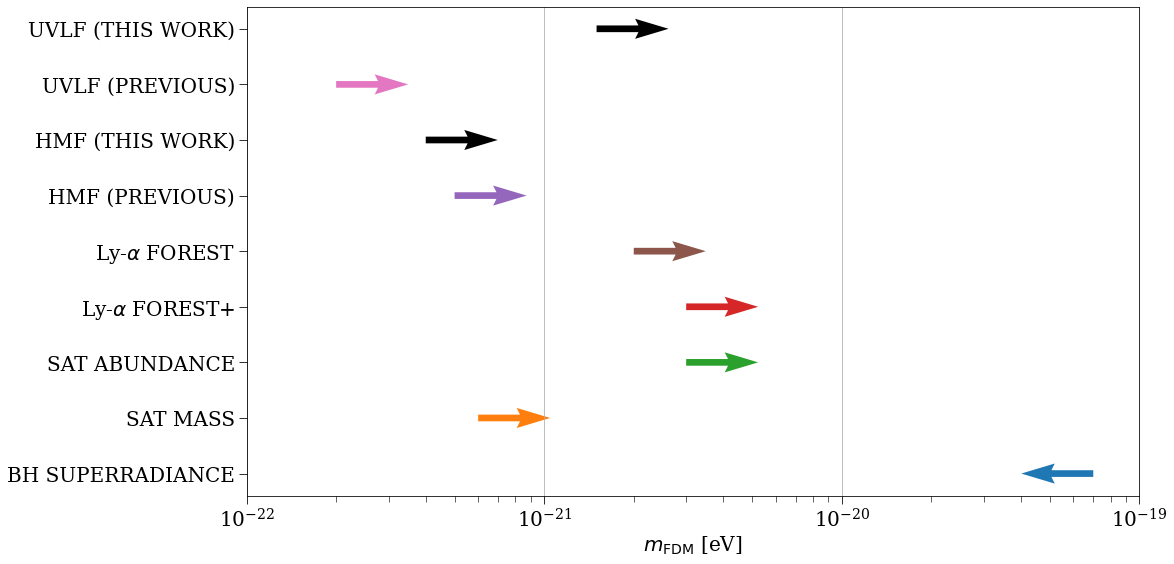

In [5]:
# Define the x values and the model names
x = np.array([7e-20, 6e-22, 3e-21, 3e-21, 2e-21, 5e-22, 4e-22, 2e-22, 1.5e-21])
models = ["BH SUPERRADIANCE", "SAT MASS", "SAT ABUNDANCE", r"Ly-$\alpha$ FOREST+", r"Ly-$\alpha$ FOREST",r"HMF (PREVIOUS)", r"HMF (THIS WORK)", r"UVLF (PREVIOUS)", r"UVLF (THIS WORK)"]

# Create a figure and an axis
fig = plt.figure()
plt.grid(False)
ax = fig.add_subplot(111)

# # Plot the arrows pointing to the right
u = 0.1*np.ones_like(x)
u[0] = -u[0]
v = np.zeros_like(u)
colors = ['C0', 'C1', 'C2', 'C3', 'C5', 'C4', 'black', 'C6', 'black']
ax.quiver(x, models, u, v, angles="xy", scale_units="inches", scale=0.1, color=colors)

# Set the axis limits and labels
ax.set_xlim(1e-22, 1e-19)
#ax.set_ylim(-0.5, 4.5)
ax.set_xlabel(r"$m_{\rm FDM}$ [eV]")
ax.set_xscale('log')
#ax.set_ylabel("Constraint Source")
ax.xaxis.grid(True)

# Show the plot
plt.show()

/home/jsipple/.conda/envs/jsipple/lib/python3.7/site-packages/ipykernel_launcher.py:8: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  


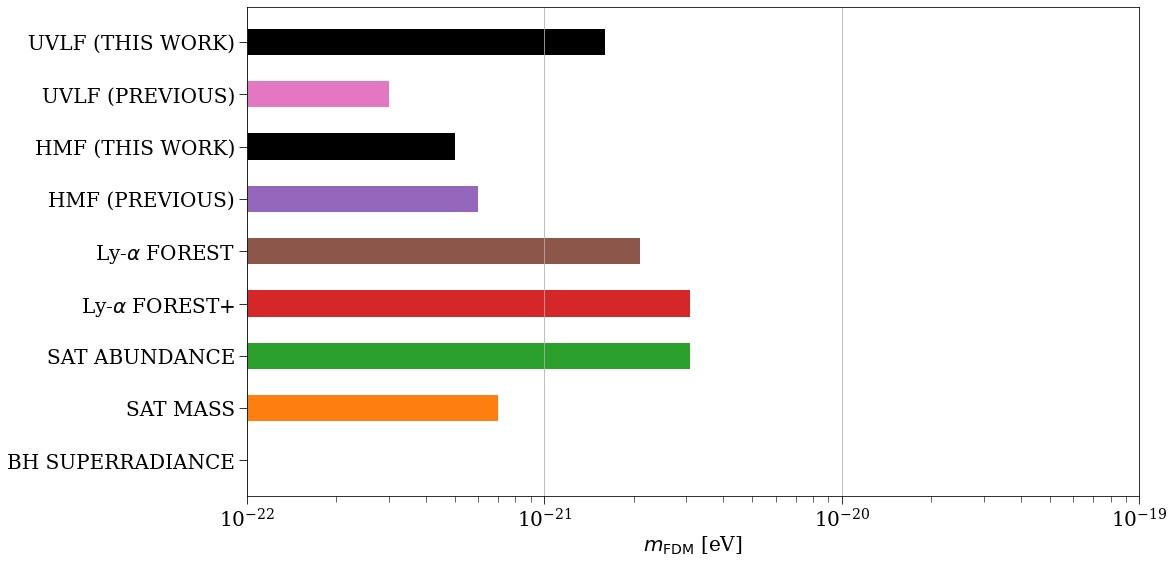

In [31]:
# Define the x values and the model names
x = np.array([7e-20, 6e-22, 3e-21, 3e-21, 2e-21, 5e-22, 4e-22, 2e-22, 1.5e-21])
models = ["BH SUPERRADIANCE", "SAT MASS", "SAT ABUNDANCE", r"Ly-$\alpha$ FOREST+", r"Ly-$\alpha$ FOREST",r"HMF (PREVIOUS)", r"HMF (THIS WORK)", r"UVLF (PREVIOUS)", r"UVLF (THIS WORK)"]

# Create a figure and an axis
fig = plt.figure()
plt.grid(False)
ax = fig.add_subplot(111)

# # Plot the arrows pointing to the right
u = 0.1*np.ones_like(x)
u[0] = -u[0]
v = np.zeros_like(u)
colors = ['C0', 'C1', 'C2', 'C3', 'C5', 'C4', 'black', 'C6', 'black']
for i, model in enumerate(models):
    width = x[i]+1e-22
    if i == 0:
        width = -1e-22
    ax.barh(model, width=width, height=0.5, align='center', color=colors[i])
#ax.quiver(x, models, u, v, angles="xy", scale_units="inches", scale=0.1, color=colors)

# Set the axis limits and labels
ax.set_xlim(1e-22, 1e-19)
#ax.set_ylim(-0.5, 4.5)
ax.set_xlabel(r"$m_{\rm FDM}$ [eV]")
ax.set_xscale('log')
#ax.set_ylabel("Constraint Source")
ax.xaxis.grid(True)

# Show the plot
plt.show()

/home/jsipple/.conda/envs/jsipple/lib/python3.7/site-packages/ipykernel_launcher.py:9: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  if __name__ == '__main__':


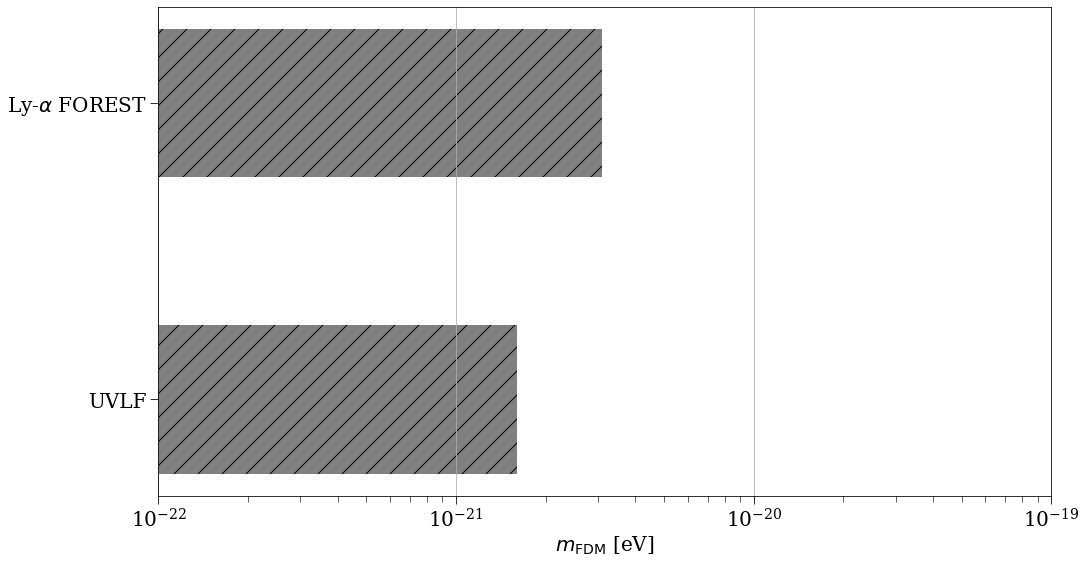

In [36]:
upper_lims = np.array([1.5e-21, 4.5e-22, 3e-21])
authors = ['THIS WORK (Section 3)', 'THIS WORK (Section 4)', 'Irsic et al. 2017',]
sources = [r"UVLF", r"UVLF", r"Ly-$\alpha$ FOREST",]
colors = ['gray', 'gray', 'red']
hatches = ['/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']

fig = plt.figure()
plt.grid(False)
ax = fig.add_subplot(111)

k=0
for i, author in enumerate(authors):
    source = sources[i]
    color = colors[i]
    if k != 0 and source[k-1] != source[k]:
        k = 0
    hatch = hatches[k]
    width = upper_lims[i]+1e-22
    ax.barh(source, width=width, height=0.5, align='center', color=colors, hatch=hatch)
    k += 1

# Set the axis limits and labels
ax.set_xlim(1e-22, 1e-19)
#ax.set_ylim(-0.5, 4.5)
ax.set_xlabel(r"$m_{\rm FDM}$ [eV]")
ax.set_xscale('log')
#ax.set_ylabel("Constraint Source")
ax.xaxis.grid(True)

# Show the plot
plt.show()

dict_items([('name', 'UVLF'), ('papers', ['THIS WORK (SECTION 3)', 'THIS WORK (SECTION 4)']), ('constraints', [1.5e-21, 4.5e-22])])
dict_items([('name', 'Ly-$\\alpha$ Forest'), ('papers', ['Irsic 2017']), ('constraints', [3e-21])])


/home/jsipple/.conda/envs/jsipple/lib/python3.7/site-packages/ipykernel_launcher.py:38: MatplotlibDeprecationWarning: Passing the minor parameter of set_yticks() positionally is deprecated since Matplotlib 3.2; the parameter will become keyword-only two minor releases later.


(1e-22, 1e-19)

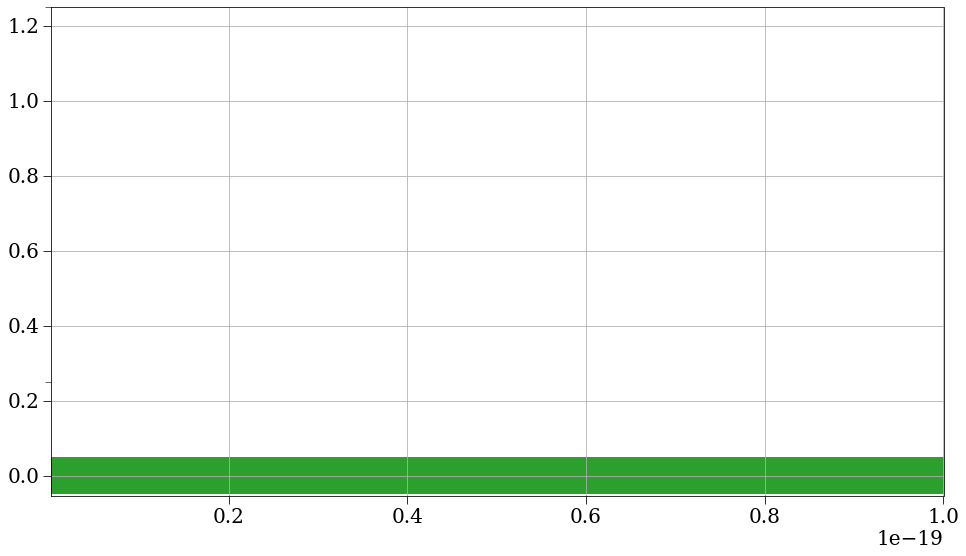

In [64]:
import matplotlib.pyplot as plt
import numpy as np

source1 = {
    'name': 'UVLF',
    'papers': ['THIS WORK (SECTION 3)', 'THIS WORK (SECTION 4)'],
    'constraints': [1.5e-21, 4.5e-22],
}
source2 = {
    'name': r"Ly-$\alpha$ Forest",
    'papers': ['Irsic 2017'],
    'constraints': [3e-21],
}
sources = [source1, source2]

x = np.arange(len(sources))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots()
all_names = []
for s in sources:
    print(s.items())
    name = s['name']
    all_names.append('name')
    papers = s['papers']
    constraints = s['constraints']
    for p, c in list(zip(papers, constraints)):
        offset = width * multiplier
        rects = ax.barh(c+1e-22, width=x + offset, height=0.1, label=c)
        #rects = ax.barh(c+1e-22, width=x + offset, height=1e-22, label=c)
        #ax.bar_label(rects, padding=3)
        multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
# ax.set_xlabel('Length (mm)')
# ax.set_title('Penguin attributes by species')
ax.set_yticks(x + width, all_names)
# ax.legend(loc='upper left', ncol=3)
# ax.set_xlim(0, 250)
ax.set_xlim(1e-22, 1e-19)

<Figure size 576x432 with 0 Axes>

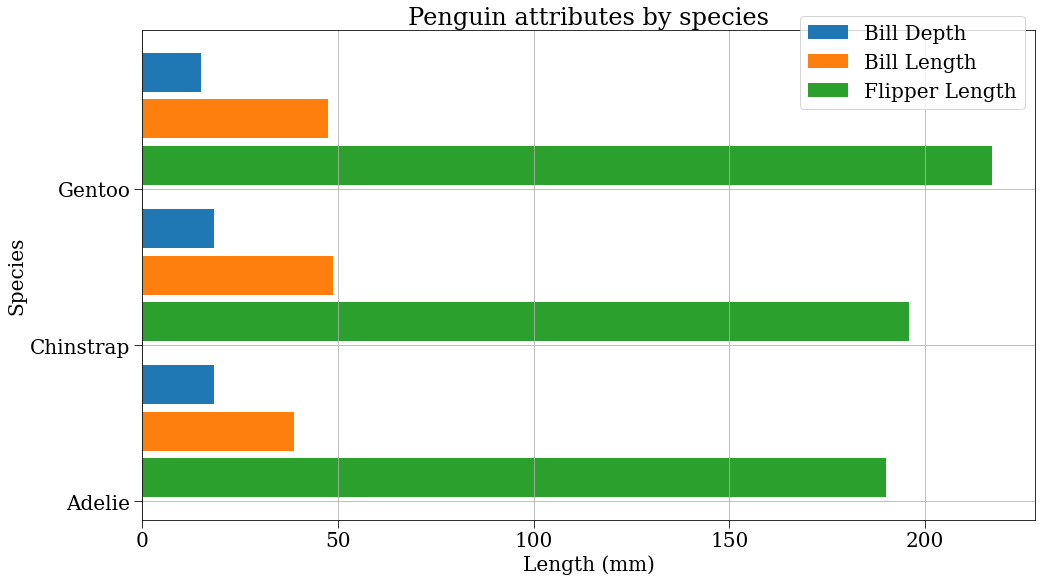

In [49]:


# Set the figure size and adjust the padding
plt.figure(figsize=(8, 6))
plt.subplots_adjust(left=0.15, right=0.95, bottom=0.1, top=0.9)

# Create an array for the horizontal bar's position
species = ("Adelie", "Chinstrap", "Gentoo")
y_pos = np.arange(len(species))

# Initialize the bar's width and the gap between the bars
width = 0.25
gap = 0.05

# Create a figure and a subplot
fig, ax = plt.subplots()

# Loop over the attributes and plot the data
penguin_means = {
    'Bill Depth': (18.35, 18.43, 14.98),
    'Bill Length': (38.79, 48.83, 47.50),
    'Flipper Length': (189.95, 195.82, 217.19),
}
for i, (attribute, measurement) in enumerate(penguin_means.items()):
    # Plot the horizontal bars with the appropriate position, width, color, and label
    ax.barh(y_pos - i * (width + gap), measurement, width, label=attribute)

# Set the y-axis ticks and labels
ax.set_yticks(y_pos - 2.5 * (width + gap))
ax.set_yticklabels(species)

# Add some labels and titles
ax.set_xlabel('Length (mm)')
ax.set_ylabel('Species')
ax.set_title('Penguin attributes by species')

# Add a legend
ax.legend(loc='upper right', bbox_to_anchor=(1, 1.05))

# Show the plot
plt.show()


[0.    1.075 1.775 2.225]
[1.5e-21, 4.5e-22, 5e-22, 2e-22]
[1e-21, 3e-21, 2e-20]
[6e-22]
[3e-21]


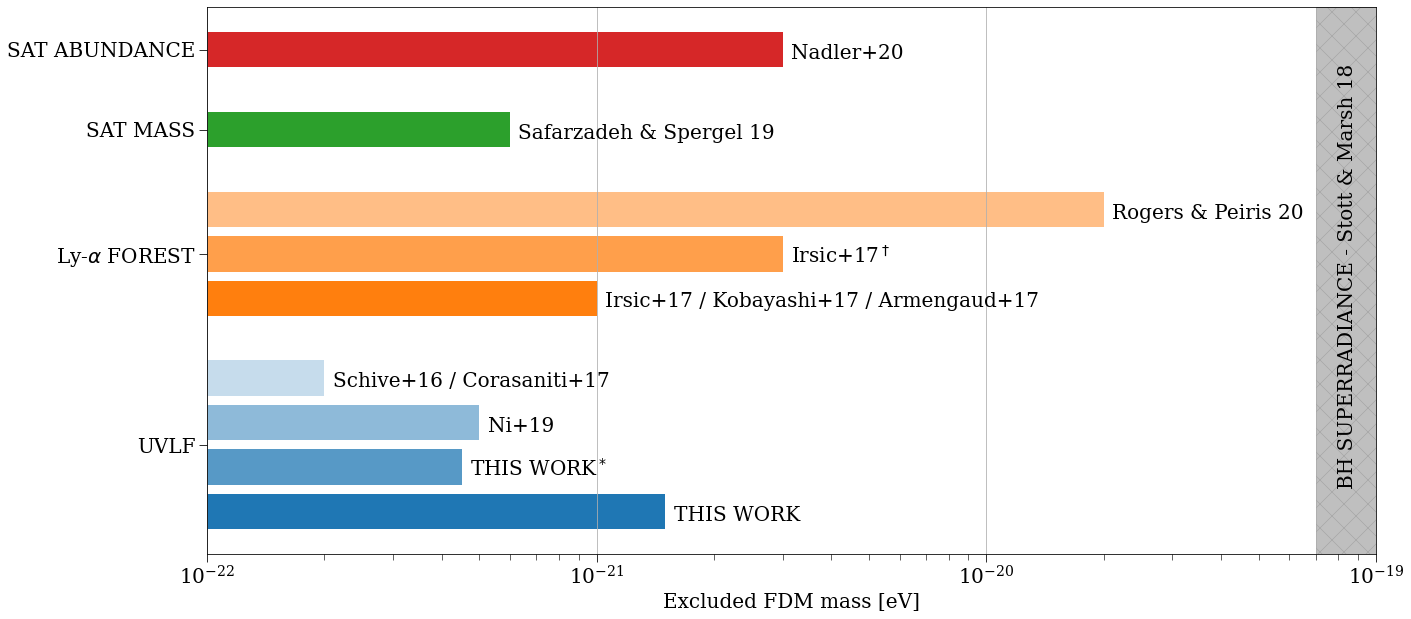

In [108]:
import matplotlib as mpl
mpl.rc('hatch', color='k', linewidth=0.5)

# Set the figure size and adjust the padding
plt.figure(figsize=(20,9))

# Create an array for the horizontal bar's position
methods = ["UVLF", r"Ly-$\alpha$ FOREST", 'SAT MASS', 'SAT ABUNDANCE']
yticks = np.arange(len(methods))

# Initialize the bar's width and the gap between the bars
width = 0.2
gap = 0.05

# Loop over the methods and plot the data
papers = [["THIS WORK", r"THIS WORK$^*$", "Ni+19", "Schive+16 / Corasaniti+17"], ["Irsic+17 / Kobayashi+17 / Armengaud+17", r'Irsic+17$^\dagger$', "Rogers & Peiris 20"], ["Safarzadeh & Spergel 19"], ['Nadler+20']]
constraint_values = [[1.5e-21, 4.5e-22, 5e-22, 2e-22], [1e-21, 3e-21, 2e-20], [6e-22], [3e-21]]
colors = ["red", "green", "blue", 'purple']
colors = ['C0', 'C1', 'C2', 'C3']
hatches = ["/", "\\", "|", "-"]
hatches = 100*['']

yticks = np.zeros(len(methods))
for i in range(1, len(methods)):
    yticks[i] += yticks[i-1] + len(papers[i-1])*(width+gap)/2 + len(papers[i])*(width+gap)/2 + width
print(yticks)

for i, method in enumerate(methods):
    # Generate some random data for each method
    n_papers = int(len(papers[i]))
    data = constraint_values[i]
    papers_for_method = papers[i]
    print(data)
    # Plot the horizontal bars with the appropriate position, width, color, hatch, and label
    for k, datum in enumerate(data):
        #bars = plt.barh(i + n_papers * width/2 + (n_papers-1)*gap/2 - k * (width + gap), datum, width, color=colors[i], hatch=hatches[k], alpha=1-0.25*k)
        loc = yticks[i] + k*(width+gap) - (n_papers-1)/2 * (width+gap)
        bars = plt.barh(loc, datum, width, color=colors[i], hatch=hatches[k], alpha=1-0.25*k)
        plt.text(1.05*datum, loc-gap, papers_for_method[k], fontdict={'fontsize':20})
        #plt.bar_label(bars, labels=[f'{x:,.2f}' for x in bars.datavalues])

plt.axvspan(7e-20, 1e-18, color='gray', alpha=0.5, hatch='x')
plt.text(8e-20, 0.95, 'BH SUPERRADIANCE - Stott & Marsh 18', rotation=90, verticalalignment='center')

# Set the x-axis ticks and labels
plt.xscale('log')
plt.xlim(1e-22, 1e-19)
# Add some labels and titles
plt.xlabel("Excluded FDM mass [eV]")
plt.yticks(ticks=yticks, labels=methods)
plt.grid(False, axis='y')
plt.tight_layout()
# Add a legend
#plt.legend()
plt.savefig('../simplify/lf/figs/fdm/summary.pdf')

In [7]:
z = 8
self = plotter_fuzzy.models[0].meas
mask = (self.z_vals == z) & (self.phis != 0)
plus_z = self.sig_pluses[mask]
minus_z = self.sig_minuses[mask]
phis_z = self.phis[mask]
naive_lower_sigma = np.sqrt(np.sum(minus_z**2))
print(np.sum(phis_z) - 2*naive_lower_sigma)

0.049288789733275995


In [8]:
n_CDM_dict = utils.load_mf()

def n_gtr_marsh(lo, m22, z):
    marsh_model = MarshCLF(meas_fn=path+'FiducialCLF/meas.npz', params=[0,0,0,0,0,1/m22])
    hi = 1e15
    integrand = lambda M: marsh_model.dn_dM(M=M, z=z)
    return utils.trapz_integrate(integrand, lo, hi, logspace=True)

def f_FDM(M, m22):
    M0 = 1.6e10 * m22**(-4/3)
    return (1 + (M/M0)**-1.1)**-2.2
def n_FDM(m22, z, is_cdm=False):
    n_CDM_z = n_CDM_dict[z]
    if is_cdm:
        return n_CDM_z
    return lambda M: n_CDM_z(M) * f_FDM(M=M, m22=m22)

def n_gtr(lo, m22, z, is_cdm=False):
    hi = 1e15
    integrand = n_FDM(m22=m22, z=z, is_cdm=is_cdm)
    return utils.trapz_integrate(integrand, lo, hi, logspace=True)

../simplify/utils.py:165: RuntimeWarning: divide by zero encountered in log
  logy = np.log(y)


5 8.18e-02
8 4.93e-02
9 2.57e-03


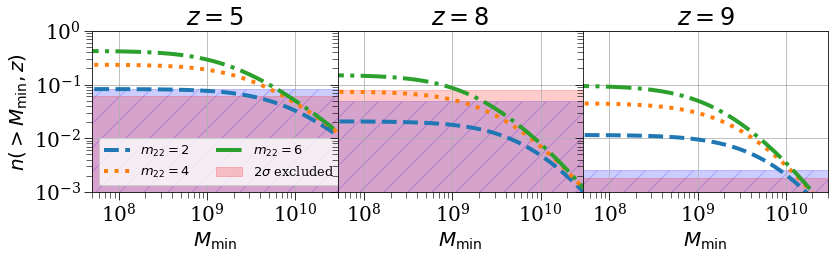

In [21]:
arr = np.load(path+'ReciprocalFuzzyCLF/tots_and_loglikes.npz')
arr2 = np.load(path+'ReciprocalFuzzyCLF/tots_and_loglikes_fsolve.npz')   

m22_list = [2,4,6]
zvals = [5,8,9]
M_los = np.logspace(7, 11, 100)
figsize=(12,4)
fig, axes = plt.subplots(
            1, 3, sharex='all', sharey=True, figsize=figsize)
axs = np.ravel(axes, order='F')
for i, z in enumerate(zvals):


    ax = axs[i]
    tots_z = arr2[f'z{z}_tots']
    loglikes_z = arr2[f'z{z}_loglikes']
    tots_from_loglikes = interp1d(loglikes_z, tots_z, fill_value='extrapolate')
    s0, s1, s2 = 0.5*tots_from_loglikes(0), 0.5*tots_from_loglikes(-0.5), 0.5*tots_from_loglikes(-2)
    n_maximums = [[n_gtr(lo=M, m22=m22, z=z) for M in M_los] for m22 in m22_list]

    self = plotter_fuzzy.models[0].meas
    mask = (self.z_vals == z) & (self.phis != 0)
    plus_z = self.sig_pluses[mask]
    minus_z = self.sig_minuses[mask]
    phis_z = self.phis[mask]
    naive_lower_sigma = np.sqrt(np.sum(minus_z**2))
    naive_bound = np.sum(phis_z) - 2*naive_lower_sigma
    print(z, f'{naive_bound:.2e}')
    ax.fill_between(x=M_los, y1=1e-4, y2=naive_bound, color='blue', alpha=0.2, zorder=-99, hatch='/')

    if i == 0:
        #ax.axhline(y=s0, color='k', linestyle='-', label=r'$\ln\: L=0$')
        #ax.axhline(y=s1, color='k', linestyle='--', label=r'$\ln\: L=-\frac{1}{2}$')
        #ax.axhline(y=s2, color='k', linestyle='-', label=r'$2\sigma$ excluded')
        ax.fill_between(x=M_los, y1=1e-4, y2=s2, color='red', alpha=0.2, zorder=-99, label=r'$2\sigma$ excluded')
    else:
        #ax.axhline(y=s0, color='k', linestyle='-')
        #ax.axhline(y=s1, color='k', linestyle='--')
        #ax.axhline(y=s2, color='k', linestyle='-')
        ax.fill_between(x=M_los, y1=1e-4, y2=s2, color='red', alpha=0.2, zorder=-99)
    if i == 0:
        [ax.loglog(M_los, n_maximums[i], label=rf'$m_{{22}}={m22}$', ls=utils.LINESTYLE_ARR[i+1]) for i, m22 in enumerate(m22_list)]
    else:
        [ax.loglog(M_los, n_maximums[i], ls=utils.LINESTYLE_ARR[i+1]) for i, m22 in enumerate(m22_list)]

    if i == 0:
        ax.legend(fontsize=13, ncol=2)
        ax.set_ylabel(r'$n(>M_{\rm min},z)$')
    ax.set_xlabel(r'$M_{\rm min}$')
    ax.set_title(fr'$z={z}$')

plt.ylim(1e-3, 1e0)
plt.xlim(5e7, 3e10)
plt.tight_layout()
plt.subplots_adjust(hspace=0, wspace=0)
plt.savefig('../simplify/lf/figs/fdm/cumulative.pdf')

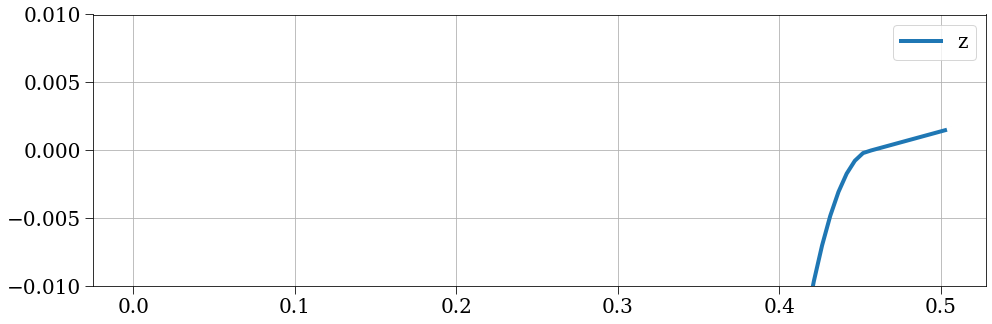

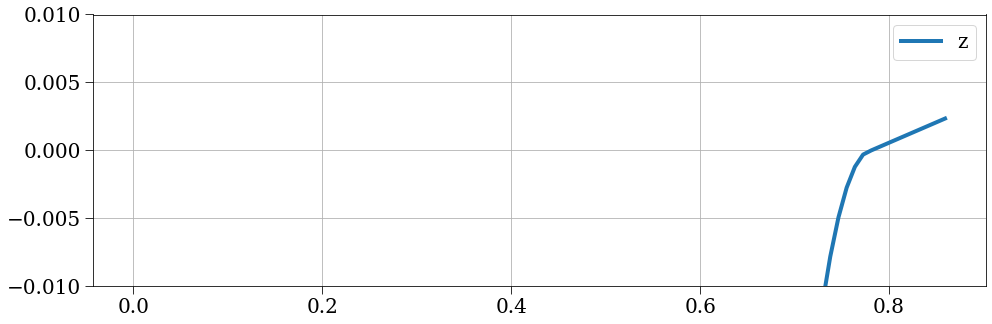

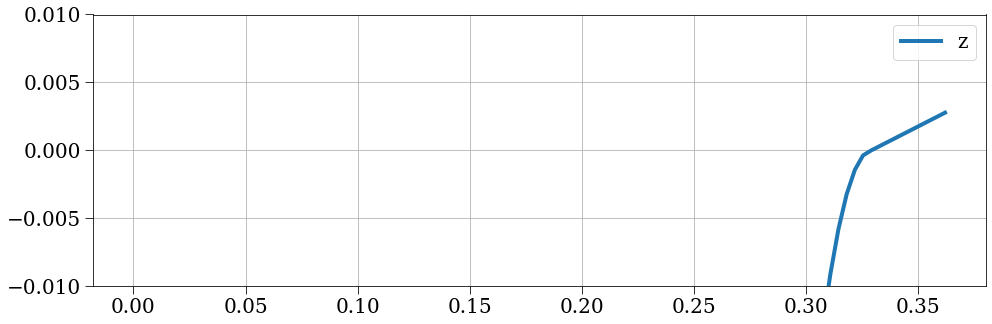

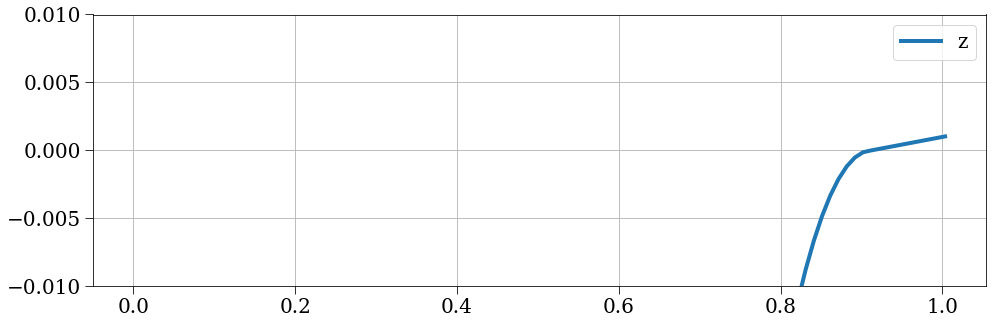

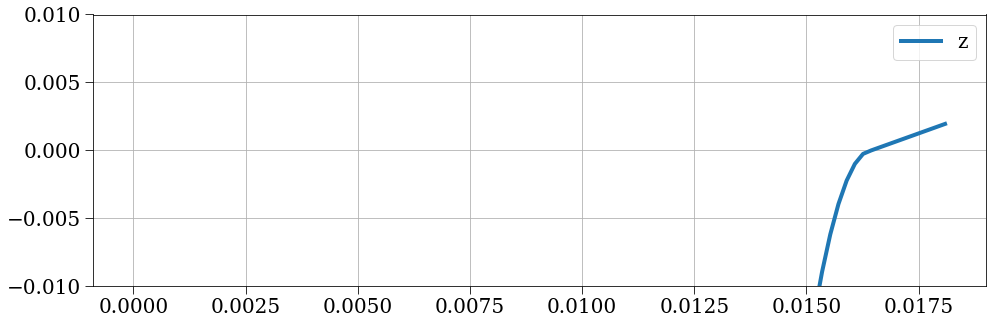

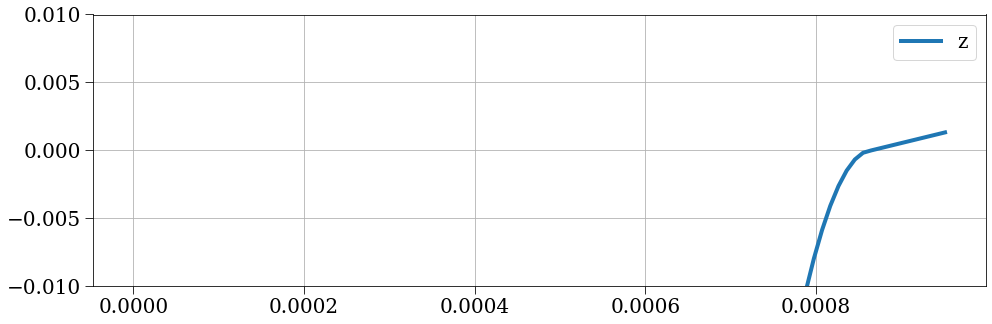

In [94]:
arr = np.load(path+'ReciprocalFuzzyCLF/tots_and_loglikes.npz')
arr2 = np.load(path+'ReciprocalFuzzyCLF/tots_and_loglikes_fsolve.npz')
for z in np.arange(5,11):
    plt.figure(figsize=[16,5])
    tots_z = arr[f'z{z}_tots']
    loglikes_z = arr[f'z{z}_loglikes']
    loglikes_from_tots = interp1d(tots_z, loglikes_z, fill_value='extrapolate')
    tots = np.linspace(tots_z[0], 1.1*tots_z[-1], 100)
    plt.plot(tots, loglikes_from_tots(tots), label='z')
    plt.ylim(-0.01, 0.01)
    plt.legend()

In [97]:
arr = np.load(path+'ReciprocalFuzzyCLF/tots_and_loglikes.npz')
arr2 = np.load(path+'ReciprocalFuzzyCLF/tots_and_loglikes_fsolve.npz')
def opt_func(m22, sigma=2, tl_arr=arr, M_lo=1e7):
    tot = 0
    ll = -sigma*2 / 2
    for z in np.arange(5,11):
        fdm_value = n_gtr(lo=M_lo, m22=m22, z=z)
        tots_z = tl_arr[f'z{z}_tots']
        loglikes_z = tl_arr[f'z{z}_loglikes']
        loglikes_from_tots = interp1d(tots_z, loglikes_z, fill_value='extrapolate')
        #print(z, loglikes_from_tots(2*fdm_value)) 
        tot += min(loglikes_from_tots(2*fdm_value),0)
    return (tot - ll)**2

def opt_func2(m22, sigma=2, tl_arr=arr, M_lo=1e7):
    tot = 0
    ll = -sigma*2 / 2
    for z in np.arange(5,11):
        fdm_value = n_gtr(lo=M_lo, m22=m22, z=z)
        self = plotter_fuzzy.models[0].meas
        mask = (self.z_vals == z) & (self.phis != 0)
        plus_z = self.sig_pluses[mask]
        minus_z = self.sig_minuses[mask]
        phis_z = self.phis[mask]
        zero_sig = np.sum(phis_z)
        naive_lower_sigma = np.sqrt(np.sum(minus_z**2))
        naive_bound = zero_sig - naive_lower_sigma
        fdm_phi_val = 2*fdm_value
        if fdm_phi_val > zero_sig:
            penalty = 0
        else:
            sig_away = (zero_sig - fdm_phi_val)/naive_lower_sigma
            # print(z, sig_away)
            penalty = -sig_away**2/2
        tot += penalty
    # print(tot, penalty)
    return (tot - ll)**2


opt = scipy.optimize.minimize(fun=opt_func, x0=5, args=(5,arr))
print(opt.x, opt.fun, opt.success)
opt2 = scipy.optimize.minimize(fun=opt_func2, x0=2, args=(5,arr))
print(opt2.x, opt2.fun)

[3.8815081] 7.730335227354186e-16 True
[3.5030212] 5.217076629545549e-14


In [76]:
opt_func2(m22=5.02446627, sigma=2, tl_arr=arr, M_lo=1e7)

2.59489648277272e-16

In [77]:
opt_func(m22=4.4887051, sigma=2, tl_arr=arr, M_lo=1e7)

5 0.003259037762633426
6 -1.2486852233929215
7 -0.07260403163222869
8 -1.784207753692252
9 0.1129719847343755
10 0.989265959712818


7.026515454178671e-16

In [63]:
arr = np.load(path+'ReciprocalFuzzyCLF/tots_and_loglikes.npz')
arr2 = np.load(path+'ReciprocalFuzzyCLF/tots_and_loglikes_fsolve.npz')
def opt_func(m22, sigma=2, tl_arr=arr, z=8, M_lo=1e7):
    tot = 0
    ll = -sigma*2 / 2
    for z in [z]:
        fdm_value = n_gtr(lo=M_lo, m22=m22, z=z)
        tots_z = tl_arr[f'z{z}_tots']
        loglikes_z = tl_arr[f'z{z}_loglikes']
        loglikes_from_tots = interp1d(tots_z, loglikes_z, fill_value='extrapolate') 
        tot += loglikes_from_tots(2*fdm_value)
    return (tot - ll)**2

def opt_func2(m22, sigma=2, tl_arr=arr, z=8, M_lo=1e7):
    tot = 0
    ll = -sigma*2 / 2
    for z in [z]:
        fdm_value = n_gtr(lo=M_lo, m22=m22, z=z)
        self = plotter_fuzzy.models[0].meas
        mask = (self.z_vals == z) & (self.phis != 0)
        plus_z = self.sig_pluses[mask]
        minus_z = self.sig_minuses[mask]
        phis_z = self.phis[mask]
        zero_sig = np.sum(phis_z)
        naive_lower_sigma = np.sqrt(np.sum(minus_z**2))
        naive_bound = zero_sig - naive_lower_sigma
        fdm_phi_val = 2*fdm_value
        if fdm_phi_val > zero_sig:
            penalty = 0
        else:
            sig_away = (zero_sig - fdm_phi_val)/naive_lower_sigma
            penalty = -sig_away**2/2
        tot += penalty
    return (tot - ll)**2

for z in [5]:# np.arange(5,11):
    opt = scipy.optimize.minimize(fun=opt_func, x0=3, args=(2,arr,z))
    print('mine', opt.x, opt.fun, z)
    opt2 = scipy.optimize.minimize(fun=opt_func2, x0=3, args=(2,arr,z))
    print('naive', opt2.x, opt2.fun, z, opt.success)

/home/jsipple/.conda/envs/jsipple/lib/python3.7/site-packages/ipykernel_launcher.py:10: RuntimeWarning: invalid value encountered in power
  # Remove the CWD from sys.path while we load stuff.


mine [1.64474493] 6.000626866094361e-17 5
naive [-2761.58072476] nan 5 True


/home/jsipple/.conda/envs/jsipple/lib/python3.7/site-packages/ipykernel_launcher.py:10: RuntimeWarning: invalid value encountered in power
  # Remove the CWD from sys.path while we load stuff.
/home/jsipple/.conda/envs/jsipple/lib/python3.7/site-packages/ipykernel_launcher.py:10: RuntimeWarning: invalid value encountered in power
  # Remove the CWD from sys.path while we load stuff.
/home/jsipple/.conda/envs/jsipple/lib/python3.7/site-packages/ipykernel_launcher.py:10: RuntimeWarning: invalid value encountered in power
  # Remove the CWD from sys.path while we load stuff.


In [64]:
opt2 = scipy.optimize.minimize(fun=opt_func2, x0=1.5, args=(2,arr,5))
print('naive', opt2.x, opt2.fun, z, opt.success)

naive [1.27867286] 3.64191129472491e-18 5 True
